In [1]:
import os
os.chdir("..")
%pwd

'/Users/beamaia/Documents/ndb_ufes_data_organizer'

In [2]:
import pandas as pd

In [3]:
train_raw_data = pd.read_csv("data/ndb_ufes/uncontaminated_train_folds.csv")
test_raw_data = pd.read_csv("data/ndb_ufes/uncontaminated_test_fold.csv")

In [4]:
train_binary_oscc_not_oscc = train_raw_data.copy()
train_binary_oscc_displasia = train_raw_data.copy()
train_binary_displasia = train_raw_data.copy()

test_binary_oscc_not_oscc = test_raw_data.copy()
test_binary_oscc_displasia = test_raw_data.copy()
test_binary_displasia = test_raw_data.copy()

In [5]:
train_binary_oscc_not_oscc.head()

,patch,origin,public_id,lesion_id,patient_id,path,localization,larger_size,tobacco_use,alcohol_consumption,...,diagnosis,dysplasia_severity,TaskII,TaskIII,TaskIV,top_left_x,top_left_y,bottom_right_x,bottom_right_y,fold
0,p0020,11,11,101,14,0011.png,Floor of mouth,3.0,Yes,Former,...,OSCC,NaN,OSCC,Presence,OSCC,443.0,-694.0,955.0,1206.0,1
1,p0021,11,11,101,14,0011.png,Floor of mouth,3.0,Yes,Former,...,OSCC,NaN,OSCC,Presence,OSCC,689.0,-949.0,1201.0,1461.0,1
2,p0022,11,11,101,14,0011.png,Floor of mouth,3.0,Yes,Former,...,OSCC,NaN,OSCC,Presence,OSCC,567.0,-87.0,1079.0,599.0,1
3,p0023,11,11,101,14,0011.png,Floor of mouth,3.0,Yes,Former,...,OSCC,NaN,OSCC,Presence,OSCC,1260.0,-486.0,1772.0,998.0,1
4,p0024,11,11,101,14,0011.png,Floor of mouth,3.0,Yes,Former,...,OSCC,NaN,OSCC,Presence,OSCC,819.0,-365.0,1331.0,877.0,1


In [6]:
train_binary_oscc_not_oscc["class"] = train_raw_data["diagnosis"].apply(lambda x: 1 if x == "OSCC" else 0)
train_binary_oscc_not_oscc.sample(15)

,patch,origin,public_id,lesion_id,patient_id,path,localization,larger_size,tobacco_use,alcohol_consumption,...,dysplasia_severity,TaskII,TaskIII,TaskIV,top_left_x,top_left_y,bottom_right_x,bottom_right_y,fold,class
1538,p3224,109,109,62,58,0109.png,Tongue,2.0,No,No,...,NaN,OSCC,Presence,OSCC,1351.0,-772.0,1863.0,1284.0,4,1
648,p0533,115,115,56,53,0115.png,Tongue,5.0,Not informed,Not informed,...,NaN,OSCC,Presence,OSCC,790.0,-554.0,1302.0,1066.0,2,1
2035,p0415,99,99,83,77,0099.png,Floor of mouth,1.0,Not informed,Not informed,...,NaN,OSCC,Presence,OSCC,912.0,-251.0,1424.0,763.0,5,1
973,p2673,194,194,38,36,0194.png,Gingiva,3.0,Not informed,Not informed,...,NaN,OSCC,Presence,OSCC,183.0,-704.0,695.0,1216.0,2,1
81,p0144,5,5,87,81,0005.png,Lip,1.5,Former,Yes,...,NaN,OSCC,Presence,OSCC,465.0,-585.0,977.0,1097.0,1,1
1789,p1315,183,183,91,85,0183.png,Tongue,0.5,Not informed,Not informed,...,NaN,Leukoplakia,Absence,Leukoplakia without dysplasia,1096.0,-93.0,1608.0,605.0,4,0
2088,p0831,215,215,37,35,0215.png,Palate,0.3,Not informed,Not informed,...,Severe,Leukoplakia,Presence,Leukoplakia with dysplasia,247.0,-660.0,759.0,1172.0,5,0
1183,p3110,175,175,89,83,0175.png,Floor of mouth,0.0,Not informed,Not informed,...,NaN,OSCC,Presence,OSCC,102.0,-169.0,614.0,681.0,3,1
1420,p2191,117,117,59,56,0117.png,Buccal mucosa,2.0,Yes,No,...,Moderate,Leukoplakia,Presence,Leukoplakia with dysplasia,1111.0,-705.0,1623.0,1217.0,3,0
760,p2332,141,141,67,62,0141.png,Gingiva,0.1,Not informed,Not informed,...,NaN,Leukoplakia,Absence,Leukoplakia without dysplasia,1288.0,-332.0,1800.0,844.0,2,0


In [10]:
test_binary_oscc_not_oscc["class"] = test_raw_data["diagnosis"].apply(lambda x: 1 if x == "OSCC" else 0)
test_binary_oscc_not_oscc.sample(15)

,patch,origin,public_id,lesion_id,patient_id,path,localization,larger_size,tobacco_use,alcohol_consumption,...,dysplasia_severity,TaskII,TaskIII,TaskIV,top_left_x,top_left_y,bottom_right_x,bottom_right_y,fold,class
311,p3367,144,144,23,21,0144.png,Gingiva,0.8,No,No,...,NaN,Leukoplakia,Absence,Leukoplakia without dysplasia,917.0,-366.0,1429.0,878.0,6,0
323,p3371,152,152,80,74,0152.png,Gingiva,0.5,Not informed,Not informed,...,NaN,Leukoplakia,Absence,Leukoplakia without dysplasia,294.0,-878.0,806.0,1390.0,6,0
310,p3366,144,144,23,21,0144.png,Gingiva,0.8,No,No,...,NaN,Leukoplakia,Absence,Leukoplakia without dysplasia,971.0,-631.0,1483.0,1143.0,6,0
254,p1919,76,76,30,27,0076.png,Lip,0.0,Yes,Former,...,Mild,Leukoplakia,Presence,Leukoplakia with dysplasia,742.0,-617.0,1254.0,1129.0,6,0
402,p2990,7,7,103,78,0007.png,Tongue,0.4,No,Yes,...,Mild,Leukoplakia,Presence,Leukoplakia with dysplasia,215.0,-367.0,727.0,879.0,6,0
126,p0573,134,134,45,43,0134.png,Floor of mouth,2.0,Yes,No,...,NaN,OSCC,Presence,OSCC,1216.0,-343.0,1728.0,855.0,6,1
244,p3327,61,61,104,60,0061.png,Tongue,0.1,Not informed,Not informed,...,NaN,OSCC,Presence,OSCC,379.0,-354.0,891.0,866.0,6,1
201,p0942,50,50,130,82,0050.png,Buccal mucosa,4.5,Not informed,Not informed,...,Severe,Leukoplakia,Presence,Leukoplakia with dysplasia,1365.0,-564.0,1877.0,1076.0,6,0
299,p1183,144,144,23,21,0144.png,Gingiva,0.8,No,No,...,NaN,Leukoplakia,Absence,Leukoplakia without dysplasia,1299.0,-706.0,1811.0,1218.0,6,0
286,p2080,102,102,83,77,0102.png,Floor of mouth,1.0,Not informed,Not informed,...,NaN,OSCC,Presence,OSCC,291.0,-407.0,803.0,919.0,6,1


In [11]:
train_binary_oscc_displasia = train_binary_oscc_displasia[train_binary_oscc_displasia["diagnosis"] != "Leukoplakia without dysplasia"]
test_binary_oscc_displasia = test_binary_oscc_displasia[test_binary_oscc_displasia["diagnosis"] != "Leukoplakia without dysplasia"]

train_binary_oscc_displasia["class"] = train_binary_oscc_displasia["diagnosis"].apply(lambda x: 1 if x == "OSCC" else 0)
test_binary_oscc_displasia["class"] = test_binary_oscc_displasia["diagnosis"].apply(lambda x: 1 if x == "OSCC" else 0)

train_binary_oscc_displasia.sample(15)

,patch,origin,public_id,lesion_id,patient_id,path,localization,larger_size,tobacco_use,alcohol_consumption,...,dysplasia_severity,TaskII,TaskIII,TaskIV,top_left_x,top_left_y,bottom_right_x,bottom_right_y,fold,class
1887,p2445,166,166,12,11,0166.png,Floor of mouth,5.0,Yes,Former,...,NaN,OSCC,Presence,OSCC,1253.0,-593.0,1765.0,1105.0,4,1
1501,p2866,73,73,31,28,0073.png,Floor of mouth,3.5,Yes,Former,...,NaN,OSCC,Presence,OSCC,1191.0,-520.0,1703.0,1032.0,4,1
1988,p0241,31,31,77,71,0031.png,Lip,0.3,No,No,...,NaN,OSCC,Presence,OSCC,1230.0,-529.0,1742.0,1041.0,5,1
1049,p0229,18,18,11,10,0018.png,Palate,1.5,Former,No,...,NaN,OSCC,Presence,OSCC,1318.0,-709.0,1830.0,1221.0,3,1
1487,p3421,41,41,84,78,0041.png,Tongue,0.4,No,Yes,...,Mild,Leukoplakia,Presence,Leukoplakia with dysplasia,218.0,-996.0,730.0,1508.0,4,0
163,p2264,78,78,42,40,0078.png,Tongue,1.0,Not informed,Not informed,...,Severe,Leukoplakia,Presence,Leukoplakia with dysplasia,964.0,-921.0,1476.0,1433.0,1,0
2240,p1651,52,52,130,82,0052.png,Buccal mucosa,4.5,Not informed,Not informed,...,Severe,Leukoplakia,Presence,Leukoplakia with dysplasia,250.0,-1012.0,762.0,1524.0,5,0
135,p2173,111,111,62,58,0111.png,Tongue,2.0,No,No,...,NaN,OSCC,Presence,OSCC,570.0,-866.0,1082.0,1378.0,1,1
1950,p2794,208,208,20,18,0208.png,Gingiva,3.0,Former,Former,...,NaN,OSCC,Presence,OSCC,1406.0,-119.0,1918.0,631.0,4,1
53,p0118,11,11,101,14,0011.png,Floor of mouth,3.0,Yes,Former,...,NaN,OSCC,Presence,OSCC,78.0,-772.0,590.0,1284.0,1,1


In [12]:
train_binary_displasia = train_binary_displasia[train_binary_displasia["diagnosis"] != "OSCC"]
test_binary_displasia = test_binary_displasia[test_binary_displasia["diagnosis"] != "OSCC"]

train_binary_displasia["class"] = train_binary_displasia["diagnosis"].apply(lambda x: 1 if x == "Leukoplakia with dysplasia" else 0)
test_binary_displasia["class"] = test_binary_displasia["diagnosis"].apply(lambda x: 1 if x == "Leukoplakia with dysplasia" else 0)

train_binary_displasia.sample(15)

,patch,origin,public_id,lesion_id,patient_id,path,localization,larger_size,tobacco_use,alcohol_consumption,...,dysplasia_severity,TaskII,TaskIII,TaskIV,top_left_x,top_left_y,bottom_right_x,bottom_right_y,fold,class
835,p1549,25,25,68,63,0025.png,Gingiva,0.7,Not informed,Not informed,...,NaN,Leukoplakia,Absence,Leukoplakia without dysplasia,850.0,-634.0,1362.0,1146.0,2,0
2192,p3400,197,197,70,65,0197.png,Buccal mucosa,1.5,No,Yes,...,Mild,Leukoplakia,Presence,Leukoplakia with dysplasia,1535.0,-271.0,2047.0,783.0,5,1
1672,p3339,182,182,26,24,0182.png,Buccal mucosa,2.0,Not informed,Not informed,...,Mild,Leukoplakia,Presence,Leukoplakia with dysplasia,34.0,-586.0,546.0,1098.0,4,1
2270,p1868,71,71,73,67,0071.png,Gingiva,1.5,Yes,No,...,NaN,Leukoplakia,Absence,Leukoplakia without dysplasia,68.0,-632.0,580.0,1144.0,5,0
499,p3044,90,90,78,72,0090.png,Gingiva,4.5,Not informed,Not informed,...,NaN,Leukoplakia,Absence,Leukoplakia without dysplasia,626.0,-657.0,1138.0,1169.0,1,0
1330,p1345,195,195,70,65,0195.png,Buccal mucosa,1.5,No,Yes,...,Mild,Leukoplakia,Presence,Leukoplakia with dysplasia,931.0,-870.0,1443.0,1382.0,3,1
2155,p1134,120,120,1,1,0120.png,Gingiva,1.0,Not informed,Not informed,...,Mild,Leukoplakia,Presence,Leukoplakia with dysplasia,1281.0,-615.0,1793.0,1127.0,5,1
347,p1070,93,93,78,72,0093.png,Gingiva,4.5,Not informed,Not informed,...,NaN,Leukoplakia,Absence,Leukoplakia without dysplasia,940.0,-666.0,1452.0,1178.0,1,0
1468,p1432,41,41,84,78,0041.png,Tongue,0.4,No,Yes,...,Mild,Leukoplakia,Presence,Leukoplakia with dysplasia,723.0,-280.0,1235.0,792.0,4,1
2107,p1525,23,23,22,20,0023.png,Gingiva,2.0,Former,No,...,NaN,Leukoplakia,Absence,Leukoplakia without dysplasia,429.0,-364.0,941.0,876.0,5,0


In [13]:
import matplotlib.pyplot as plt
import numpy as np

In [14]:
folds_train_binary_oscc_not_oscc = train_binary_oscc_not_oscc[["fold", "class"]]
folds_test_binary_oscc_not_oscc = test_binary_oscc_not_oscc[["fold", "class"]]
folds_train_binary_oscc_displasia = train_binary_oscc_displasia[["fold", "class"]]
folds_test_binary_oscc_displasia = test_binary_oscc_displasia[["fold", "class"]]
folds_train_binary_displasia = train_binary_displasia[["fold", "class"]]
folds_test_binary_displasia = test_binary_displasia[["fold", "class"]]

In [15]:
folds_train_binary_oscc_not_oscc_1 = pd.DataFrame(folds_train_binary_oscc_not_oscc[folds_train_binary_oscc_not_oscc["fold"] == 1].value_counts(normalize=True))
folds_train_binary_oscc_not_oscc_2 = pd.DataFrame(folds_train_binary_oscc_not_oscc[folds_train_binary_oscc_not_oscc["fold"] == 2].value_counts(normalize=True))
folds_train_binary_oscc_not_oscc_3 = pd.DataFrame(folds_train_binary_oscc_not_oscc[folds_train_binary_oscc_not_oscc["fold"] == 3].value_counts(normalize=True))
folds_train_binary_oscc_not_oscc_4 = pd.DataFrame(folds_train_binary_oscc_not_oscc[folds_train_binary_oscc_not_oscc["fold"] == 4].value_counts(normalize=True))
folds_train_binary_oscc_not_oscc_5 = pd.DataFrame(folds_train_binary_oscc_not_oscc[folds_train_binary_oscc_not_oscc["fold"] == 5].value_counts(normalize=True))
folds_test_binary_oscc_not_oscc_6 = pd.DataFrame(folds_test_binary_oscc_not_oscc[folds_test_binary_oscc_not_oscc["fold"] == 6].value_counts(normalize=True))

prop_folds_train_binary_oscc_not_oscc = pd.concat([folds_train_binary_oscc_not_oscc_1,
                                                    folds_train_binary_oscc_not_oscc_2,
                                                    folds_train_binary_oscc_not_oscc_3,
                                                    folds_train_binary_oscc_not_oscc_4,
                                                    folds_train_binary_oscc_not_oscc_5,
                                                    folds_test_binary_oscc_not_oscc_6])
prop_folds_train_binary_oscc_not_oscc

proportion
fold class            
1    0        0.519409
     1        0.480591
2    0        0.502058
     1        0.497942
3    0        0.523585
     1        0.476415
4    0        0.545098
     1        0.454902
5    1        0.582915
     0        0.417085
6    0        0.502000
     1        0.498000

In [16]:
folds_train_binary_oscc_displasia_1 = pd.DataFrame(folds_train_binary_oscc_displasia[folds_train_binary_oscc_displasia["fold"] == 1].value_counts(normalize=True))
folds_train_binary_oscc_displasia_2 = pd.DataFrame(folds_train_binary_oscc_displasia[folds_train_binary_oscc_displasia["fold"] == 2].value_counts(normalize=True))
folds_train_binary_oscc_displasia_3 = pd.DataFrame(folds_train_binary_oscc_displasia[folds_train_binary_oscc_displasia["fold"] == 3].value_counts(normalize=True))
folds_train_binary_oscc_displasia_4 = pd.DataFrame(folds_train_binary_oscc_displasia[folds_train_binary_oscc_displasia["fold"] == 4].value_counts(normalize=True))
folds_train_binary_oscc_displasia_5 = pd.DataFrame(folds_train_binary_oscc_displasia[folds_train_binary_oscc_displasia["fold"] == 5].value_counts(normalize=True))
folds_test_binary_oscc_displasia_6 = pd.DataFrame(folds_test_binary_oscc_displasia[folds_test_binary_oscc_displasia["fold"] == 6].value_counts(normalize=True))

prop_folds_train_binary_oscc_displasia = pd.concat([folds_train_binary_oscc_displasia_1,
                                                    folds_train_binary_oscc_displasia_2,
                                                    folds_train_binary_oscc_displasia_3,
                                                    folds_train_binary_oscc_displasia_4,
                                                    folds_train_binary_oscc_displasia_5,
                                                    folds_test_binary_oscc_displasia_6])
prop_folds_train_binary_oscc_displasia

proportion
fold class            
1    1        0.575221
     0        0.424779
2    1        0.672222
     0        0.327778
3    1        0.604790
     0        0.395210
4    1        0.552381
     0        0.447619
5    1        0.709480
     0        0.290520
6    1        0.640103
     0        0.359897

In [17]:
folds_train_binary_displasia_1 = pd.DataFrame(folds_train_binary_displasia[folds_train_binary_displasia["fold"] == 1].value_counts(normalize=True))
folds_train_binary_displasia_2 = pd.DataFrame(folds_train_binary_displasia[folds_train_binary_displasia["fold"] == 2].value_counts(normalize=True))
folds_train_binary_displasia_3 = pd.DataFrame(folds_train_binary_displasia[folds_train_binary_displasia["fold"] == 3].value_counts(normalize=True))
folds_train_binary_displasia_4 = pd.DataFrame(folds_train_binary_displasia[folds_train_binary_displasia["fold"] == 4].value_counts(normalize=True))
folds_train_binary_displasia_5 = pd.DataFrame(folds_train_binary_displasia[folds_train_binary_displasia["fold"] == 5].value_counts(normalize=True))
folds_test_binary_displasia_6 = pd.DataFrame(folds_test_binary_displasia[folds_test_binary_displasia["fold"] == 6].value_counts(normalize=True))

prop_folds_train_binary_displasia = pd.concat([folds_train_binary_displasia_1,
                                                    folds_train_binary_displasia_2,
                                                    folds_train_binary_displasia_3,
                                                    folds_train_binary_displasia_4,
                                                    folds_train_binary_displasia_5,
                                                    folds_test_binary_displasia_6])
prop_folds_train_binary_displasia

proportion
fold class            
1    1        0.683274
     0        0.316726
2    0        0.516393
     1        0.483607
3    1        0.594595
     0        0.405405
4    1        0.676259
     0        0.323741
5    1        0.572289
     0        0.427711
6    1        0.557769
     0        0.442231

In [18]:
plt.rcParams["figure.figsize"] = 18,5

def create_folds_prop(diagnosis_names, df, ax, title):
    folds_per = {
        '1': round(df.query("fold == 1")["proportion"] * 100,2), 
        '2': round(df.query("fold == 2")["proportion"] * 100,2),
        '3': round(df.query("fold == 3")["proportion"] * 100,2),
        '4': round(df.query("fold == 4")["proportion"] * 100,2),
        '5': round(df.query("fold == 5")["proportion"] * 100,2),
        '6': round(df.query("fold == 6")["proportion"] * 100,2)
    }

    x = np.arange(len(diagnosis_names))  # the label locations
    width = 0.15 # the width of the bars
    multiplier = 0

    for attribute, measurement in folds_per.items():
        offset = width * multiplier
        rects = ax.bar(x + offset, measurement, width, label=attribute, align='edge')
        ax.bar_label(rects, padding=5)
        multiplier += 1

    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set_ylabel('Percentage')
    ax.set_title(title)
    ax.set_xticks(x + width + 0.3, diagnosis_names)
    ax.legend(loc='upper left', ncols=6)
    ax.set_ylim(0, 100)


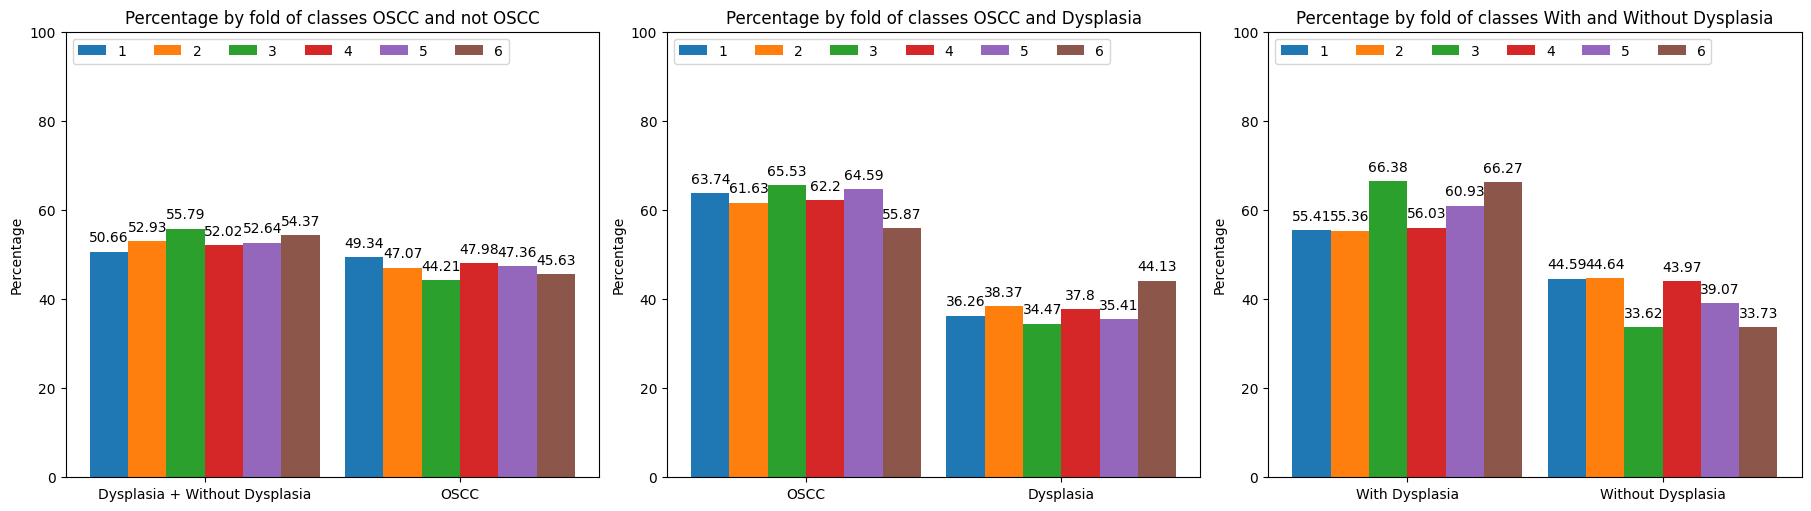

In [87]:
fig, ax = plt.subplots(1, 3, layout='constrained')

diagnosis_names = ["Dysplasia + Without Dysplasia", "OSCC"]
create_folds_prop(diagnosis_names, prop_folds_train_binary_oscc_not_oscc, ax[0], "Percentage by fold of classes OSCC and not OSCC")

diagnosis_names = ["OSCC", "Dysplasia"]
create_folds_prop(diagnosis_names, prop_folds_train_binary_oscc_displasia, ax[1], "Percentage by fold of classes OSCC and Dysplasia")

diagnosis_names = ["With Dysplasia", "Without Dysplasia"]
create_folds_prop(diagnosis_names, prop_folds_train_binary_displasia, ax[2], "Percentage by fold of classes With and Without Dysplasia")

In [19]:
folds_train_binary_oscc_displasia_1 = pd.DataFrame(folds_train_binary_oscc_displasia[folds_train_binary_oscc_displasia["fold"] == 1].value_counts(normalize=False))
folds_train_binary_oscc_displasia_2 = pd.DataFrame(folds_train_binary_oscc_displasia[folds_train_binary_oscc_displasia["fold"] == 2].value_counts(normalize=False))
folds_train_binary_oscc_displasia_3 = pd.DataFrame(folds_train_binary_oscc_displasia[folds_train_binary_oscc_displasia["fold"] == 3].value_counts(normalize=False))
folds_train_binary_oscc_displasia_4 = pd.DataFrame(folds_train_binary_oscc_displasia[folds_train_binary_oscc_displasia["fold"] == 4].value_counts(normalize=False))
folds_train_binary_oscc_displasia_5 = pd.DataFrame(folds_train_binary_oscc_displasia[folds_train_binary_oscc_displasia["fold"] == 5].value_counts(normalize=False))
folds_test_binary_oscc_displasia_6 = pd.DataFrame(folds_test_binary_oscc_displasia[folds_test_binary_oscc_displasia["fold"] == 6].value_counts(normalize=False))

num_folds_train_binary_oscc_displasia = pd.concat([folds_train_binary_oscc_displasia_1,
                                                    folds_train_binary_oscc_displasia_2,
                                                    folds_train_binary_oscc_displasia_3,
                                                    folds_train_binary_oscc_displasia_4,
                                                    folds_train_binary_oscc_displasia_5,
                                                    folds_test_binary_oscc_displasia_6])
num_folds_train_binary_oscc_displasia

count
fold class       
1    1        260
     0        192
2    1        242
     0        118
3    1        202
     0        132
4    1        232
     0        188
5    1        232
     0         95
6    1        249
     0        140

In [20]:
folds_train_binary_oscc_not_oscc_1 = pd.DataFrame(folds_train_binary_oscc_not_oscc[folds_train_binary_oscc_not_oscc["fold"] == 1].value_counts(normalize=False))
folds_train_binary_oscc_not_oscc_2 = pd.DataFrame(folds_train_binary_oscc_not_oscc[folds_train_binary_oscc_not_oscc["fold"] == 2].value_counts(normalize=False))
folds_train_binary_oscc_not_oscc_3 = pd.DataFrame(folds_train_binary_oscc_not_oscc[folds_train_binary_oscc_not_oscc["fold"] == 3].value_counts(normalize=False))
folds_train_binary_oscc_not_oscc_4 = pd.DataFrame(folds_train_binary_oscc_not_oscc[folds_train_binary_oscc_not_oscc["fold"] == 4].value_counts(normalize=False))
folds_train_binary_oscc_not_oscc_5 = pd.DataFrame(folds_train_binary_oscc_not_oscc[folds_train_binary_oscc_not_oscc["fold"] == 5].value_counts(normalize=False))
folds_test_binary_oscc_not_oscc_6 = pd.DataFrame(folds_test_binary_oscc_not_oscc[folds_test_binary_oscc_not_oscc["fold"] == 6].value_counts(normalize=False))

num_folds_train_binary_oscc_not_oscc = pd.concat([folds_train_binary_oscc_not_oscc_1,
                                                    folds_train_binary_oscc_not_oscc_2,
                                                    folds_train_binary_oscc_not_oscc_3,
                                                    folds_train_binary_oscc_not_oscc_4,
                                                    folds_train_binary_oscc_not_oscc_5,
                                                    folds_test_binary_oscc_not_oscc_6])
num_folds_train_binary_oscc_not_oscc

count
fold class       
1    0        281
     1        260
2    0        244
     1        242
3    0        222
     1        202
4    0        278
     1        232
5    1        232
     0        166
6    0        251
     1        249

In [21]:
folds_train_binary_displasia_1 = pd.DataFrame(folds_train_binary_displasia[folds_train_binary_displasia["fold"] == 1].value_counts(normalize=False))
folds_train_binary_displasia_2 = pd.DataFrame(folds_train_binary_displasia[folds_train_binary_displasia["fold"] == 2].value_counts(normalize=False))
folds_train_binary_displasia_3 = pd.DataFrame(folds_train_binary_displasia[folds_train_binary_displasia["fold"] == 3].value_counts(normalize=False))
folds_train_binary_displasia_4 = pd.DataFrame(folds_train_binary_displasia[folds_train_binary_displasia["fold"] == 4].value_counts(normalize=False))
folds_train_binary_displasia_5 = pd.DataFrame(folds_train_binary_displasia[folds_train_binary_displasia["fold"] == 5].value_counts(normalize=False))
folds_test_binary_displasia_6 = pd.DataFrame(folds_test_binary_displasia[folds_test_binary_displasia["fold"] == 6].value_counts(normalize=False))

num_folds_train_binary_displasia = pd.concat([folds_train_binary_displasia_1,
                                                    folds_train_binary_displasia_2,
                                                    folds_train_binary_displasia_3,
                                                    folds_train_binary_displasia_4,
                                                    folds_train_binary_displasia_5,
                                                    folds_test_binary_displasia_6])
num_folds_train_binary_displasia

count
fold class       
1    1        192
     0         89
2    0        126
     1        118
3    1        132
     0         90
4    1        188
     0         90
5    1         95
     0         71
6    1        140
     0        111

In [22]:
desc_bin_dysplasia = pd.concat([num_folds_train_binary_displasia, prop_folds_train_binary_displasia], axis=1).add_prefix("bin_dysplasia1_no_dysplasia0_", axis=1)
desc_bin_oscc_dysplasia = pd.concat([num_folds_train_binary_oscc_displasia, prop_folds_train_binary_oscc_displasia], axis=1).add_prefix("bin_oscc1_dysplasia0_", axis=1)
desc_bin_oscc_no_oscc = pd.concat([num_folds_train_binary_oscc_not_oscc, prop_folds_train_binary_oscc_not_oscc], axis=1).add_prefix("bin_oscc1_not_oscc0_", axis=1)

In [23]:
desc_folds = pd.concat([desc_bin_oscc_no_oscc, desc_bin_oscc_dysplasia, desc_bin_dysplasia], axis=1).sort_index()

In [24]:
import pathlib as pl

In [25]:
ndb_ufes_path = pl.Path("data/ndb_ufes")

In [28]:
train_binary_oscc_not_oscc.to_csv(ndb_ufes_path / "bin_oscc_not_oscc_folds_train.csv", index=False)
test_binary_oscc_not_oscc.to_csv(ndb_ufes_path / "bin_oscc_not_oscc_folds_test.csv", index=False)
train_binary_oscc_displasia.to_csv(ndb_ufes_path / "bin_oscc_dysplasia_folds_train.csv", index=False)
test_binary_oscc_displasia.to_csv(ndb_ufes_path / "bin_oscc_dysplasia_folds_test.csv", index=False)
train_binary_displasia.to_csv(ndb_ufes_path / "bin_dysplasia_no_dysplasia_folds_train.csv", index=False)
test_binary_displasia.to_csv(ndb_ufes_path / "bin_dysplasia_no_dysplasia_folds_test.csv", index=False)
desc_folds.to_csv(ndb_ufes_path / "description_binary_folds.csv")

In [29]:
os.makedirs(ndb_ufes_path / "artifacts")

FileExistsError: [Errno 17] File exists: 'data/ndb_ufes/artifacts'

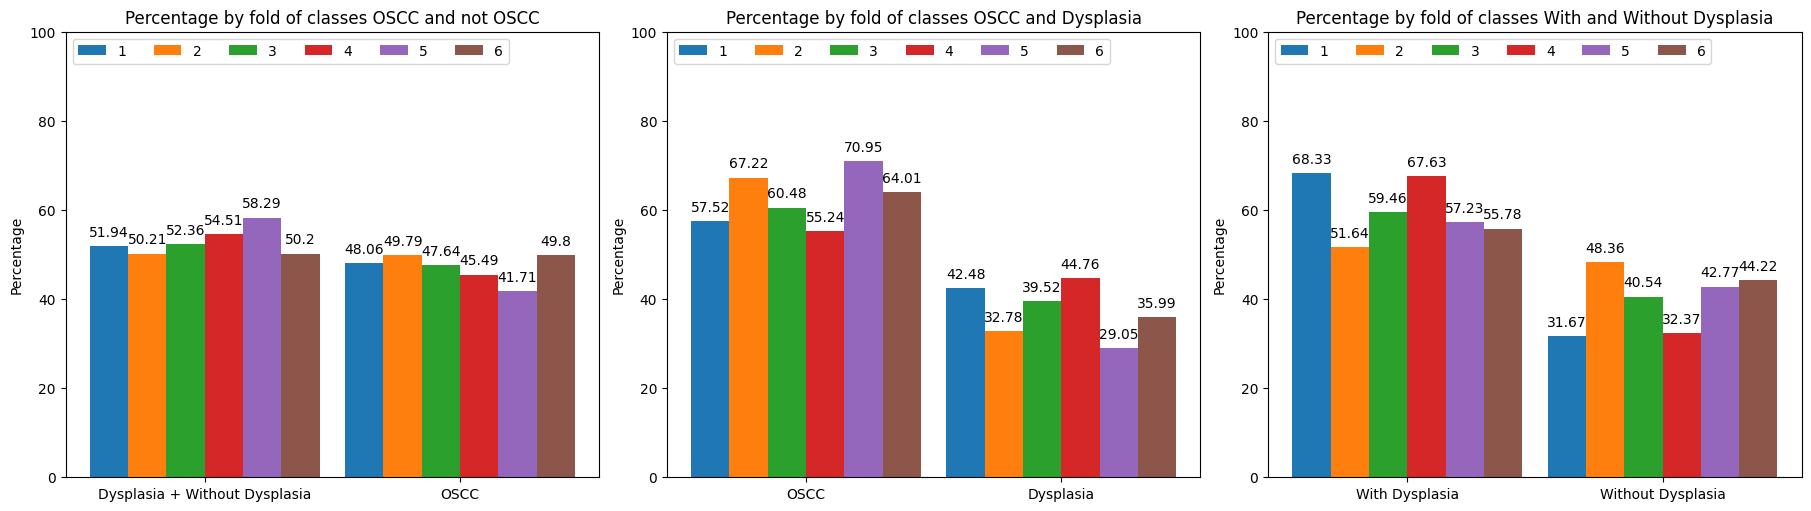

In [31]:
fig, ax = plt.subplots(1, 3, layout='constrained')

diagnosis_names = ["Dysplasia + Without Dysplasia", "OSCC"]
create_folds_prop(diagnosis_names, prop_folds_train_binary_oscc_not_oscc, ax[0], "Percentage by fold of classes OSCC and not OSCC")

diagnosis_names = ["OSCC", "Dysplasia"]
create_folds_prop(diagnosis_names, prop_folds_train_binary_oscc_displasia, ax[1], "Percentage by fold of classes OSCC and Dysplasia")

diagnosis_names = ["With Dysplasia", "Without Dysplasia"]
create_folds_prop(diagnosis_names, prop_folds_train_binary_displasia, ax[2], "Percentage by fold of classes With and Without Dysplasia")

plt.savefig(ndb_ufes_path / "artifacts" / "binary_folds_proportions.png")

In [32]:
train_multiclass_data = train_raw_data.copy()
test_multiclass_data = test_raw_data.copy()

train_multiclass_data["class"] = train_multiclass_data["diagnosis"].apply(lambda x: 0 if x == "Leukoplakia without dysplasia" \
                                                                          else 1 if x=="Leukoplakia with dysplasia" \
                                                                          else 2)
test_multiclass_data["class"] = test_multiclass_data["diagnosis"].apply(lambda x: 0 if x == "Leukoplakia without dysplasia" \
                                                                        else 1 if x=="Leukoplakia with dysplasia" \
                                                                        else 2)

In [33]:
train_multiclass_data.head(15)

,patch,origin,public_id,lesion_id,patient_id,path,localization,larger_size,tobacco_use,alcohol_consumption,...,dysplasia_severity,TaskII,TaskIII,TaskIV,top_left_x,top_left_y,bottom_right_x,bottom_right_y,fold,class
0,p0020,11,11,101,14,0011.png,Floor of mouth,3.0,Yes,Former,...,NaN,OSCC,Presence,OSCC,443.0,-694.0,955.0,1206.0,1,2
1,p0021,11,11,101,14,0011.png,Floor of mouth,3.0,Yes,Former,...,NaN,OSCC,Presence,OSCC,689.0,-949.0,1201.0,1461.0,1,2
2,p0022,11,11,101,14,0011.png,Floor of mouth,3.0,Yes,Former,...,NaN,OSCC,Presence,OSCC,567.0,-87.0,1079.0,599.0,1,2
3,p0023,11,11,101,14,0011.png,Floor of mouth,3.0,Yes,Former,...,NaN,OSCC,Presence,OSCC,1260.0,-486.0,1772.0,998.0,1,2
4,p0024,11,11,101,14,0011.png,Floor of mouth,3.0,Yes,Former,...,NaN,OSCC,Presence,OSCC,819.0,-365.0,1331.0,877.0,1,2
5,p0025,11,11,101,14,0011.png,Floor of mouth,3.0,Yes,Former,...,NaN,OSCC,Presence,OSCC,1237.0,-187.0,1749.0,699.0,1,2
6,p0026,11,11,101,14,0011.png,Floor of mouth,3.0,Yes,Former,...,NaN,OSCC,Presence,OSCC,819.0,-426.0,1331.0,938.0,1,2
7,p0027,11,11,101,14,0011.png,Floor of mouth,3.0,Yes,Former,...,NaN,OSCC,Presence,OSCC,1490.0,-952.0,2002.0,1464.0,1,2
8,p0028,11,11,101,14,0011.png,Floor of mouth,3.0,Yes,Former,...,NaN,OSCC,Presence,OSCC,1243.0,-953.0,1755.0,1465.0,1,2
9,p0031,11,11,101,14,0011.png,Floor of mouth,3.0,Yes,Former,...,NaN,OSCC,Presence,OSCC,740.0,-525.0,1252.0,1037.0,1,2


In [35]:
folds_train_multiclass_data = train_multiclass_data[["fold", "class"]]
folds_test_multiclass_data = test_multiclass_data[["fold", "class"]]

folds_train_multiclass_data_1 = pd.DataFrame(folds_train_multiclass_data[folds_train_multiclass_data["fold"] == 1].value_counts(normalize=False))
folds_train_multiclass_data_2 = pd.DataFrame(folds_train_multiclass_data[folds_train_multiclass_data["fold"] == 2].value_counts(normalize=False))
folds_train_multiclass_data_3 = pd.DataFrame(folds_train_multiclass_data[folds_train_multiclass_data["fold"] == 3].value_counts(normalize=False))
folds_train_multiclass_data_4 = pd.DataFrame(folds_train_multiclass_data[folds_train_multiclass_data["fold"] == 4].value_counts(normalize=False))
folds_train_multiclass_data_5 = pd.DataFrame(folds_train_multiclass_data[folds_train_multiclass_data["fold"] == 5].value_counts(normalize=False))
folds_test_multiclass_data_6 = pd.DataFrame(folds_test_multiclass_data[folds_test_multiclass_data["fold"] == 6].value_counts(normalize=False))

num_folds_train_multiclass_data = pd.concat([folds_train_multiclass_data_1,
                                                    folds_train_multiclass_data_2,
                                                    folds_train_multiclass_data_3,
                                                    folds_train_multiclass_data_4,
                                                    folds_train_multiclass_data_5,
                                                    folds_test_multiclass_data_6])
num_folds_train_multiclass_data

count
fold class       
1    2        260
     1        192
     0         89
2    2        242
     0        126
     1        118
3    2        202
     1        132
     0         90
4    2        232
     1        188
     0         90
5    2        232
     1         95
     0         71
6    2        249
     1        140
     0        111

In [39]:
folds_train_multiclass_data_1 = pd.DataFrame(folds_train_multiclass_data[folds_train_multiclass_data["fold"] == 1].value_counts(normalize=True))
folds_train_multiclass_data_2 = pd.DataFrame(folds_train_multiclass_data[folds_train_multiclass_data["fold"] == 2].value_counts(normalize=True))
folds_train_multiclass_data_3 = pd.DataFrame(folds_train_multiclass_data[folds_train_multiclass_data["fold"] == 3].value_counts(normalize=True))
folds_train_multiclass_data_4 = pd.DataFrame(folds_train_multiclass_data[folds_train_multiclass_data["fold"] == 4].value_counts(normalize=True))
folds_train_multiclass_data_5 = pd.DataFrame(folds_train_multiclass_data[folds_train_multiclass_data["fold"] == 5].value_counts(normalize=True))
folds_test_multiclass_data_6 = pd.DataFrame(folds_test_multiclass_data[folds_test_multiclass_data["fold"] == 6].value_counts(normalize=True))

prop_folds_train_multiclass_data = pd.concat([folds_train_multiclass_data_1,
                                                    folds_train_multiclass_data_2,
                                                    folds_train_multiclass_data_3,
                                                    folds_train_multiclass_data_4,
                                                    folds_train_multiclass_data_5,
                                                    folds_test_multiclass_data_6])
prop_folds_train_multiclass_data

proportion
fold class            
1    2        0.480591
     1        0.354898
     0        0.164510
2    2        0.497942
     0        0.259259
     1        0.242798
3    2        0.476415
     1        0.311321
     0        0.212264
4    2        0.454902
     1        0.368627
     0        0.176471
5    2        0.582915
     1        0.238693
     0        0.178392
6    2        0.498000
     1        0.280000
     0        0.222000

In [ ]:
diagnosis_names = ["OSCC", "Dysplasia"]
create_folds_prop(diagnosis_names, prop_folds_train_binary_oscc_displasia, ax[1], "Percentage by fold of classes OSCC and Dysplasia")

diagnosis_names = ["With Dysplasia", "Without Dysplasia"]

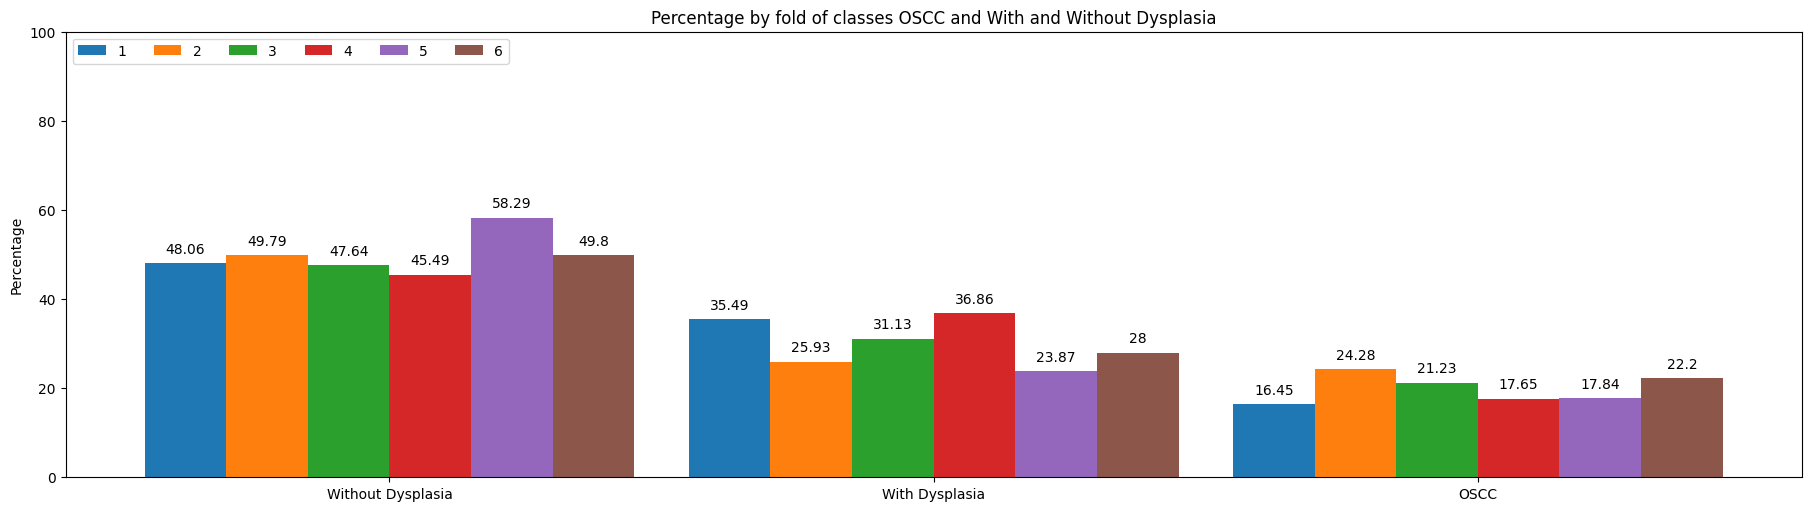

In [43]:
fig, ax = plt.subplots(1, 1, layout='constrained')
diagnosis_names = ["Without Dysplasia", "With Dysplasia", "OSCC"]
create_folds_prop(diagnosis_names, prop_folds_train_multiclass_data, ax, "Percentage by fold of classes OSCC and With and Without Dysplasia")
plt.savefig(ndb_ufes_path / "artifacts" / "multiclass_folds_proportions.png")